In [68]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter,ParameterVector
import numpy as np
from qiskit_aer import AerSimulator

In [ ]:
#SINGLE QUBIT VARIATIONAL CIRCUIT 
#EXAMPLE-1

#Parameters are initialised with a simple string identifier
parameter_0 =Parameter('θ1')
parameter_1=Parameter('θ2')


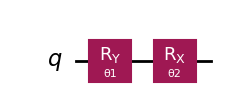

In [10]:
#Building the circuit 
circuit=QuantumCircuit(1)

#We can put the initialised parameters as rotation angles argument to Rx and Ry gates.
circuit.ry(theta=parameter_0,qubit=0)
circuit.rx(theta=parameter_1,qubit=0)
circuit.draw('mpl')

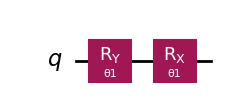

In [12]:
#EXAMPLE-2
#using same parameter twice.

circuit_2=QuantumCircuit(1)
circuit_2.ry(theta=parameter_0,qubit=0)
circuit_2.rx(theta=parameter_0,qubit=0)
circuit_2.draw('mpl')

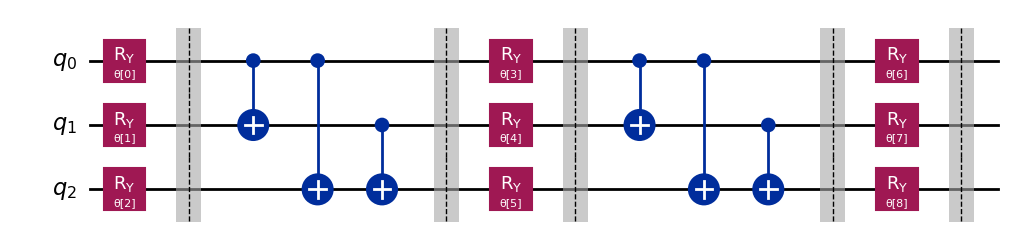

In [58]:
#EXAMPLE-3
#A REALAMPLITUTE CIRCUIT WITH ALTERNATING LAYERS OF PARAMETRISED Ry AND CNOT GATES .

#set the number of qubits and layers
num_q=3
num_layers=2

params=ParameterVector('θ',num_q*(num_layers+1))
circuit_3=QuantumCircuit(num_q)
for i in range(num_layers):
    for j in range(num_q):
        circuit_3.ry(theta=params[i*num_q+j],qubit=j)
    circuit_3.barrier()

    for j in range(num_q):
        for k in range(j):
            circuit_3.cx(k,j)
    circuit_3.barrier()
for j in range(num_q):
        circuit_3.ry(theta=params[num_layers*num_q+j],qubit=j)
circuit_3.barrier()
circuit_3.draw('mpl')


In [59]:
print(circuit_3.parameters)

ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8])])


{ParameterVectorElement(θ[0]): 0.9768503590913615, ParameterVectorElement(θ[1]): 0.6160433832675444, ParameterVectorElement(θ[2]): 0.1913094459327498, ParameterVectorElement(θ[3]): 0.833537159506806, ParameterVectorElement(θ[4]): 0.1379962060614114, ParameterVectorElement(θ[5]): 0.587968605933609, ParameterVectorElement(θ[6]): 0.6171468107085695, ParameterVectorElement(θ[7]): 0.978282037624433, ParameterVectorElement(θ[8]): 0.14071388290297704}


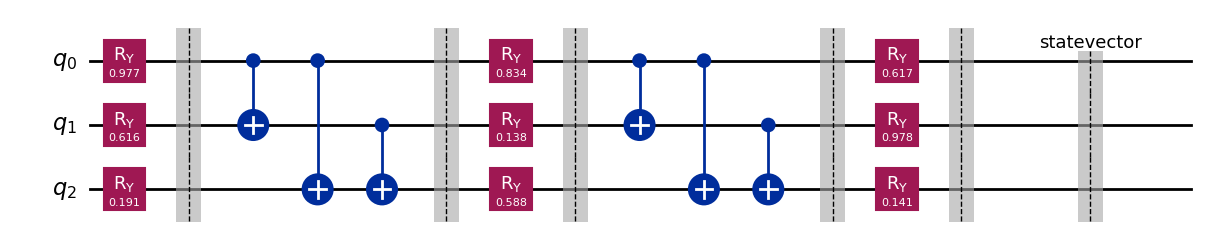

In [86]:
#ASSIGNING VALUES TO THE CIRCUIT
params_dict={parameters: np.random.random() for parameters in params}
print(params_dict)
finalcircuit=circuit_3.assign_parameters(params_dict)
finalcircuit.save_statevector() 
finalcircuit.draw("mpl")


In [80]:
import qiskit_aer
from qiskit.visualization import plot_state_city

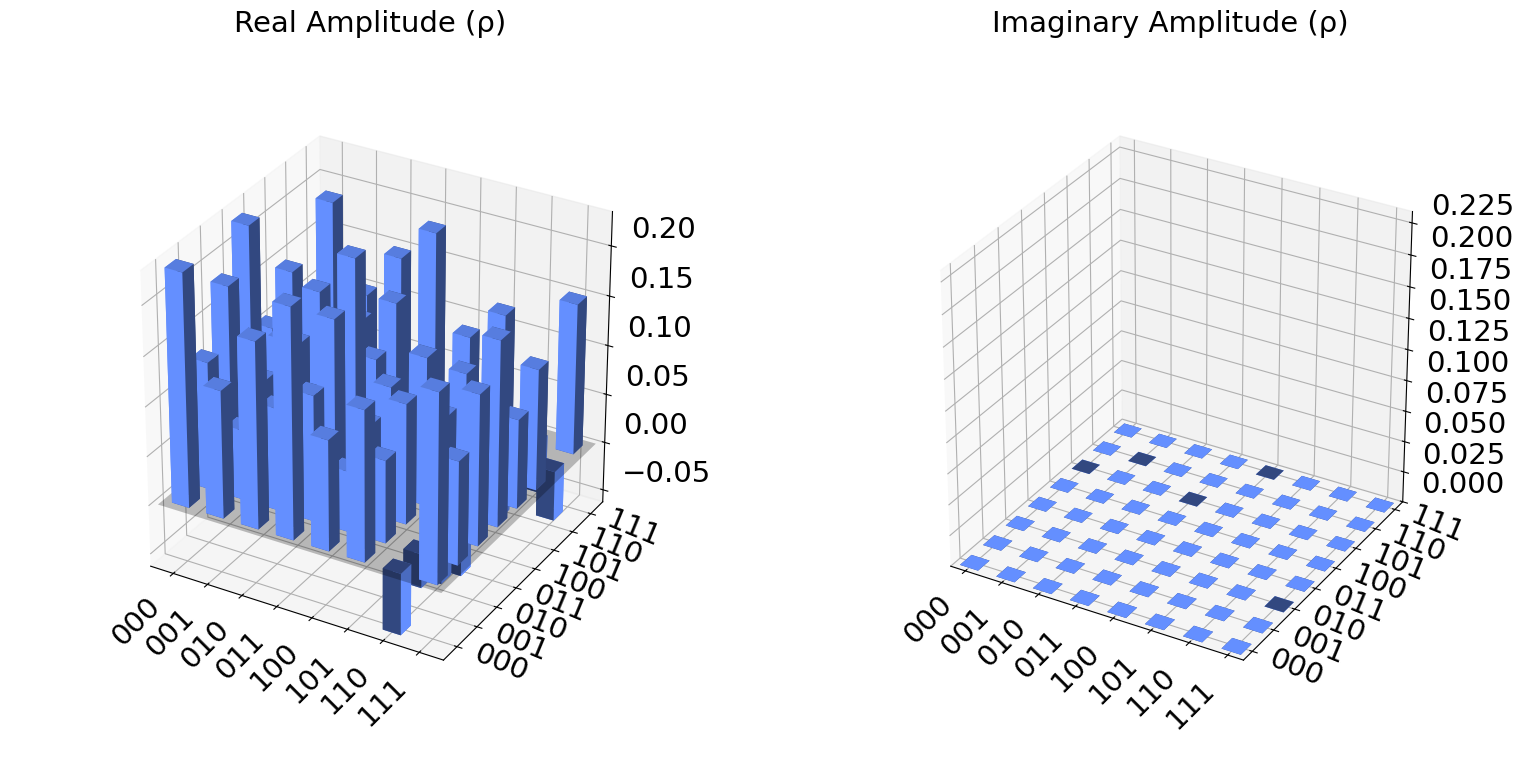

In [89]:

simulator=AerSimulator(method='statevector') 
result=simulator.run(finalcircuit).result()
state=result.get_statevector(finalcircuit)
plot_state_city(state)